## Part A — Data Collection & Preprocessing

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle


In [36]:
df = pd.read_csv(r'../datasets/student_survey.csv')
df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


Dimension Check

In [37]:
print("Shape: ",df.shape)

Shape:  (50, 15)


Column Names

In [38]:
print(df.columns)

Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company that recruits from campus?',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'Your CIA % of last semester', 'Your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='object')


Missing Values Identification

In [39]:
df.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)

### NOISE CLEANUP

Selecting Required Columns

In [40]:
cols =[
    'Your CIA % of last semester',
    'Your GPA of last semester',
    'Your maximum attendance % till last semester'
]

data = df[cols].copy()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Your CIA % of last semester                   50 non-null     object 
 1   Your GPA of last semester                     50 non-null     float64
 2   Your maximum attendance % till last semester  50 non-null     object 
dtypes: float64(1), object(2)
memory usage: 1.3+ KB


Renaming Columns for Convenience

In [41]:
data.columns = ['CIA', 'GPA', 'Attendance']

Stripping '%' symbols and whitespaces for all the three columns

In [42]:
for col in data.columns:
    data[col] = data[col].astype(str).str.replace('%', '', regex = False).str.strip()

data

,CIA,GPA,Attendance
0,69,3.4,98
1,75,3.69,95
2,82,3.41,95
3,91,3.6,92
4,70,3.54,93
5,75,3.67,98
6,74,3.4,94
7,68,3.4,85
8,73,3.6,90
9,79,3.73,93


Converting to numeric of object types

In [43]:
data = data.apply(pd.to_numeric, errors='coerce')

data

,CIA,GPA,Attendance
0,69.00,3.40,98.00
1,75.00,3.69,95.00
2,82.00,3.41,95.00
3,91.00,3.60,92.00
4,70.00,3.54,93.00
5,75.00,3.67,98.00
6,74.00,3.40,94.00
7,68.00,3.40,85.00
8,73.00,3.60,90.00
9,79.00,3.73,93.00


Check for and drop NaN rows

In [44]:
print('Missing values:\n', data.isnull().sum())
data = data.dropna()
print("Shape after dropping NaN:", data.shape)

Missing values:
 CIA           0
GPA           0
Attendance    0
dtype: int64
Shape after dropping NaN: (50, 3)


Removing outliers/invalid values

1. GPA should be between 0 and 4
2. CIA% must be between 0-100
3. Attendance must be between 0-100


In [45]:
data = data[(data['GPA'] >= 0) & (data['GPA'] <= 4.0)]
data = data[(data['CIA'] >= 0) & (data['CIA'] <= 100)]
data = data[(data['Attendance'] >= 0) & (data['Attendance'] <= 100)]
print("Shape after removing outliers:", data.shape)

Shape after removing outliers: (49, 3)


Removing Duplicates

In [46]:
data = data.drop_duplicates()
print("Shape after removing duplicates:", data.shape)


Shape after removing duplicates: (49, 3)


Statistical Summary:


In [47]:
data.describe()

,CIA,GPA,Attendance
count,49.000000,49.000000,49.000000
mean,72.825102,3.405102,94.004898
std,6.378355,0.237023,3.674066
min,60.000000,2.740000,85.000000
25%,69.780000,3.300000,92.000000
50%,71.780000,3.400000,95.000000
75%,77.000000,3.600000,96.000000
max,91.000000,3.900000,100.000000


Identifying variables


In [48]:
# Experiment 1: X = CIA, Y = GPA
# Experiment 2: X = Attendance, Y = GPA
print("\nDependent Variable (Y): GPA")
print("Independent Variables (X): CIA (Exp 1), Attendance (Exp 2)")



Dependent Variable (Y): GPA
Independent Variables (X): CIA (Exp 1), Attendance (Exp 2)


## Part B — Simple Linear Regression using Scikit-learn


Since I will we run it twice, better to convert it to a function

In [57]:
from IPython.core import application
from IPython.core import application
from sklearn.linear_model import LinearRegression
def sklearn_regression(X,y,feature_name):
    # Performing linear regression using Scikit-learn

    # reshaping X to 2D
    X = X.values.reshape(-1,1)
    y = y.values

    # split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state = 42
    )

    print(f'Training Set Size: {len(X_train)}')
    print(f'Testing Set Size: {len(X_test)}')

    # training the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # getting slope and intercept
    slope = model.coef_[0]
    intercept = model.intercept_
    print(f"\nSlope (m): {slope}")
    print(f"Intercept (b): {intercept}")
    print(f"Equation: GPA = {slope:.4f} * {feature_name} + {intercept:.4f}")

    # predict on test set
    y_pred = model.predict(X_test)

    # visualize
    plt.figure(figsize=(8,5))
    plt.scatter(X_train, y_train, color='blue', label='Training data', alpha=0.6)
    plt.scatter(X_test, y_test, color='green', label='Test data(Actual)', alpha=0.6)
    plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(feature_name)
    plt.ylabel('GPA')
    plt.title(f'Linear Regression: {feature_name} vs GPA (Scikit-learn)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return model, slope, intercept, X_test, y_test, y_pred

Experiment 1: CIA% vs GPA

Exp 1: CIA Percentage -> GPA
Training Set Size: 39
Testing Set Size: 10

Slope (m): 0.01279967845914644
Intercept (b): 2.483379907389372
Equation: GPA = 0.0128 * CIA % + 2.4834


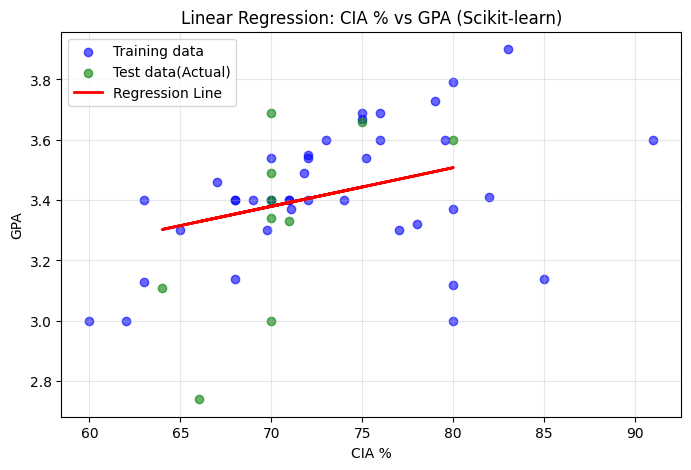

In [58]:
print('Exp 1: CIA Percentage -> GPA')

model1, slope1, intercept1,Xtest1, ytest1, ypred_sk1 = sklearn_regression(
    data['CIA'], data['GPA'], 'CIA %'
)

Experiment 2: Attendance % vs GPA

Exp 2: Attendance %age -> GPA
Training Set Size: 39
Testing Set Size: 10

Slope (m): 0.02440993165985645
Intercept (b): 1.1406546355016682
Equation: GPA = 0.0244 * Attendance % + 1.1407


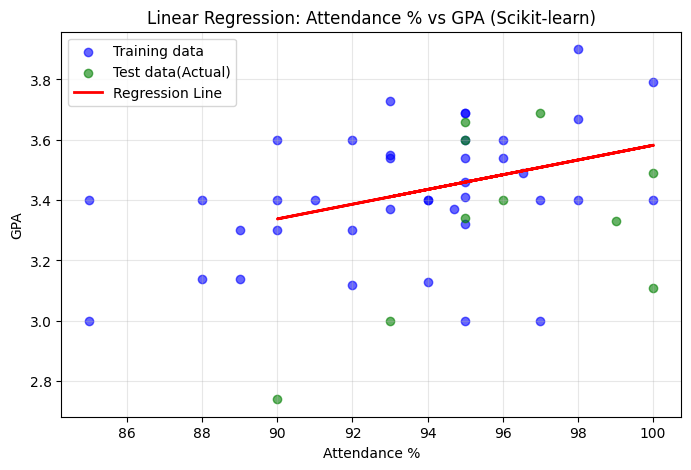

In [59]:
print('Exp 2: Attendance %age -> GPA')

model2, slope2, intercept2, Xtest2, ytest2, ypred_sk2 = sklearn_regression(
    data['Attendance'], data['GPA'], 'Attendance %'
)

## Part C — Manual OLS Computation

The Ordinary Least Squares formulas for simple linear regression y = mx + b:


Slope (m)     = [n * Σ(xi * yi) - Σxi * Σyi] / [n * Σ(xi²) - (Σxi)²]

Intercept (b) = [Σyi - m * Σxi] / n


Or equivalently:


m = Σ[(xi - x̄)(yi - ȳ)] / Σ[(xi - x̄)²]

b = ȳ - m * x̄


Implementing manual OLS function

In [60]:
def manual_ols(X, y, feature_name):
    """Compute regression line manually using OLS formulas."""
    
    n = len(X)
    
    # Method: Using means (more intuitive)
    x_mean = np.mean(X)
    y_mean = np.mean(y)
    
    # Compute slope
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    slope = numerator / denominator
    
    # Compute intercept
    intercept = y_mean - slope * x_mean
    
    print(f"\nManual OLS Results for {feature_name}:")
    print(f"n (samples): {n}")
    print(f"x_bar (mean of X): {x_mean:.4f}")
    print(f"y_bar (mean of Y): {y_mean:.4f}")
    print(f"Slope (m): {slope:.6f}")
    print(f"Intercept (b): {intercept:.6f}")
    print(f"Equation: GPA = {slope:.4f} * {feature_name} + {intercept:.4f}")
    
    # Predict using the manual equation
    y_pred = slope * X + intercept
    
    return slope, intercept, y_pred


Running manual OLS for both experiments

In [63]:
print("MANUAL OLS - EXPERIMENT 1: CIA % vs GPA")

# Use the same training split
X_train1 = data['CIA'].values.reshape(-1, 1)
y_train1_full = data['GPA'].values

# Same split as sklearn
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_train1, y_train1_full, test_size=0.2, random_state=42
)

# Manual OLS on training data
ols_slope1, ols_intercept1, _ = manual_ols(X_tr1.flatten(), y_tr1, 'CIA %')

# Predict on test data using manual equation
y_pred_ols1 = ols_slope1 * X_te1.flatten() + ols_intercept1


MANUAL OLS - EXPERIMENT 1: CIA % vs GPA

Manual OLS Results for CIA %:
n (samples): 39
x_bar (mean of X): 73.3956
y_bar (mean of Y): 3.4228
Slope (m): 0.012800
Intercept (b): 2.483380
Equation: GPA = 0.0128 * CIA % + 2.4834


In [62]:
print("MANUAL OLS - EXPERIMENT 2: Attendance % vs GPA")

X_train2 = data['Attendance'].values.reshape(-1, 1)
y_train2_full = data['GPA'].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_train2, y_train2_full, test_size=0.2, random_state=42
)

ols_slope2, ols_intercept2, _ = manual_ols(X_tr2.flatten(), y_tr2, 'Attendance %')
y_pred_ols2 = ols_slope2 * X_te2.flatten() + ols_intercept2


MANUAL OLS - EXPERIMENT 2: Attendance % vs GPA

Manual OLS Results for Attendance %:
n (samples): 39
x_bar (mean of X): 93.4933
y_bar (mean of Y): 3.4228
Slope (m): 0.024410
Intercept (b): 1.140655
Equation: GPA = 0.0244 * Attendance % + 1.1407


## Part D — Comparison Task


In [64]:
def compare_methods(y_pred_sklearn, y_pred_ols, experiment_name, sk_slope, sk_intercept, ols_slope, ols_intercept):
    # Compare Scikit-learn and OLS predictions
    
    print(f"COMPARISON: {experiment_name}")
    
    # Compare parameters
    print("\n--- Model Parameters ---")
    comparison_params = pd.DataFrame({
        'Parameter': ['Slope', 'Intercept'],
        'Scikit-learn': [sk_slope, sk_intercept],
        'Manual OLS': [ols_slope, ols_intercept],
        'Difference': [abs(sk_slope - ols_slope), abs(sk_intercept - ols_intercept)]
    })
    print(comparison_params.to_string(index=False))
    
    # Compare predictions
    print("\n--- Predictions Comparison ---")
    comparison_df = pd.DataFrame({
        'Sklearn Prediction': y_pred_sklearn,
        'OLS Prediction': y_pred_ols,
        'Difference': np.abs(y_pred_sklearn - y_pred_ols)
    })
    print(comparison_df.to_string(index=False))
    
    print(f"\nMax difference: {comparison_df['Difference'].max():.10f}")
    print(f"Mean difference: {comparison_df['Difference'].mean():.10f}")
    
    return comparison_df


Running Comparisons

In [67]:
comp1 = compare_methods(
    ypred_sk1, y_pred_ols1, "Experiment 1: CIA % vs GPA",
    slope1, intercept1, ols_slope1, ols_intercept1
)



COMPARISON: Experiment 1: CIA % vs GPA

--- Model Parameters ---
Parameter  Scikit-learn  Manual OLS   Difference
    Slope       0.01280     0.01280 1.734723e-18
Intercept       2.48338     2.48338 4.440892e-16

--- Predictions Comparison ---
 Sklearn Prediction  OLS Prediction   Difference
           3.379357        3.379357 0.000000e+00
           3.379357        3.379357 0.000000e+00
           3.328159        3.328159 0.000000e+00
           3.443356        3.443356 4.440892e-16
           3.302559        3.302559 0.000000e+00
           3.392157        3.392157 4.440892e-16
           3.379357        3.379357 0.000000e+00
           3.379357        3.379357 0.000000e+00
           3.507354        3.507354 4.440892e-16
           3.379357        3.379357 0.000000e+00

Max difference: 0.0000000000
Mean difference: 0.0000000000


In [68]:
comp2 = compare_methods(
    ypred_sk2, y_pred_ols2, "Experiment 2: Attendance % vs GPA",
    slope2, intercept2, ols_slope2, ols_intercept2
)

COMPARISON: Experiment 2: Attendance % vs GPA

--- Model Parameters ---
Parameter  Scikit-learn  Manual OLS   Difference
    Slope      0.024410    0.024410 3.469447e-18
Intercept      1.140655    1.140655 4.440892e-16

--- Predictions Comparison ---
 Sklearn Prediction  OLS Prediction   Difference
           3.581648        3.581648 0.000000e+00
           3.508418        3.508418 0.000000e+00
           3.337548        3.337548 0.000000e+00
           3.459598        3.459598 0.000000e+00
           3.581648        3.581648 0.000000e+00
           3.557238        3.557238 0.000000e+00
           3.410778        3.410778 4.440892e-16
           3.484008        3.484008 0.000000e+00
           3.459598        3.459598 0.000000e+00
           3.459598        3.459598 0.000000e+00

Max difference: 0.0000000000
Mean difference: 0.0000000000


OBSERVATIONS:
=============
1. Both Scikit-learn LinearRegression and manual OLS produce IDENTICAL (or near-identical) 
   results because Scikit-learn internally uses the same OLS formula.
2. The tiny differences (if any) are due to floating-point precision, 
   not due to any algorithmic difference.
3. This confirms that LinearRegression in Scikit-learn is essentially a convenient 
   wrapper around the OLS mathematical formulas.
4. [Add your specific observations about CIA vs Attendance correlation with GPA here]

## Part E — Parameter Saving with Pickle


Preparing and saving the parameters dictionary


In [ ]:
params = {
    'experiment_1': {
        'feature': 'CIA %',
        'slope': slope1,
        'intercept': intercept1
    },
    'experiment_2': {
        'feature': 'Attendance %',
        'slope': slope2,
        'intercept': intercept2
    }
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(params, f)

print("Parameters saved to linear_regression_weights.pkl")
print(f"Saved parameters: {params}")


Parameters saved to linear_regression_weights.pkl
Saved parameters: {'experiment_1': {'feature': 'CIA %', 'slope': 0.01279967845914644, 'intercept': 2.483379907389372}, 'experiment_2': {'feature': 'Attendance %', 'slope': 0.02440993165985645, 'intercept': 1.1406546355016682}}


Loading the saved parameters


In [ ]:
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

print("Loaded parameters:")
print(loaded_params)


Loaded parameters:
{'experiment_1': {'feature': 'CIA %', 'slope': 0.01279967845914644, 'intercept': 2.483379907389372}, 'experiment_2': {'feature': 'Attendance %', 'slope': 0.02440993165985645, 'intercept': 1.1406546355016682}}
